# fintrack — 05 Spending Visualizations
**Purpose**: Charts and graphs of spending data for exploration and validation  
before building the frontend.  
**Version**: 1.0 — 2026-03-24  

Charts included:
1. Category spend — horizontal bar chart
2. Monthly trend — line chart with MoM delta
3. Essential vs non-essential — stacked bar by month
4. Monthly pivot heatmap — categories x months
5. Utility seasonal — line chart per utility type

In [1]:
import os
import httpx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'font.family': 'sans-serif'})

API_BASE = f"http://{os.getenv('API_HOST','192.168.1.170')}:{os.getenv('API_PORT','8000')}"
EMAIL    = os.getenv('FINTRACK_EMAIL',    'your@email.com')
PASSWORD = os.getenv('FINTRACK_PASSWORD', 'yourpassword')
YEAR     = 2025

r = httpx.post(f'{API_BASE}/api/v1/auth/login',
               json={'email': EMAIL, 'password': PASSWORD}, timeout=10)
TOKEN   = r.json()['access_token']
HEADERS = {'Authorization': f'Bearer {TOKEN}'}

def api_get(path, params=None):
    r = httpx.get(f'{API_BASE}{path}', headers=HEADERS,
                  params=params, timeout=15)
    r.raise_for_status()
    return r.json()

print(f'Authenticated — loading {YEAR} data...')

# Pre-fetch all data
cat_data   = api_get('/api/v1/analytics/category-summary', {'year': YEAR})
trend_data = api_get('/api/v1/analytics/trend',            {'year': YEAR})
split_data = api_get('/api/v1/analytics/essential-split',  {'year': YEAR})
pivot_data = api_get('/api/v1/analytics/monthly-pivot',    {'year': YEAR})
util_data  = api_get('/api/v1/analytics/utility-seasonal', {'year': YEAR})
print('Data loaded')

Authenticated — loading 2025 data...
Data loaded


## Chart 1 — Spending by Category (horizontal bar)

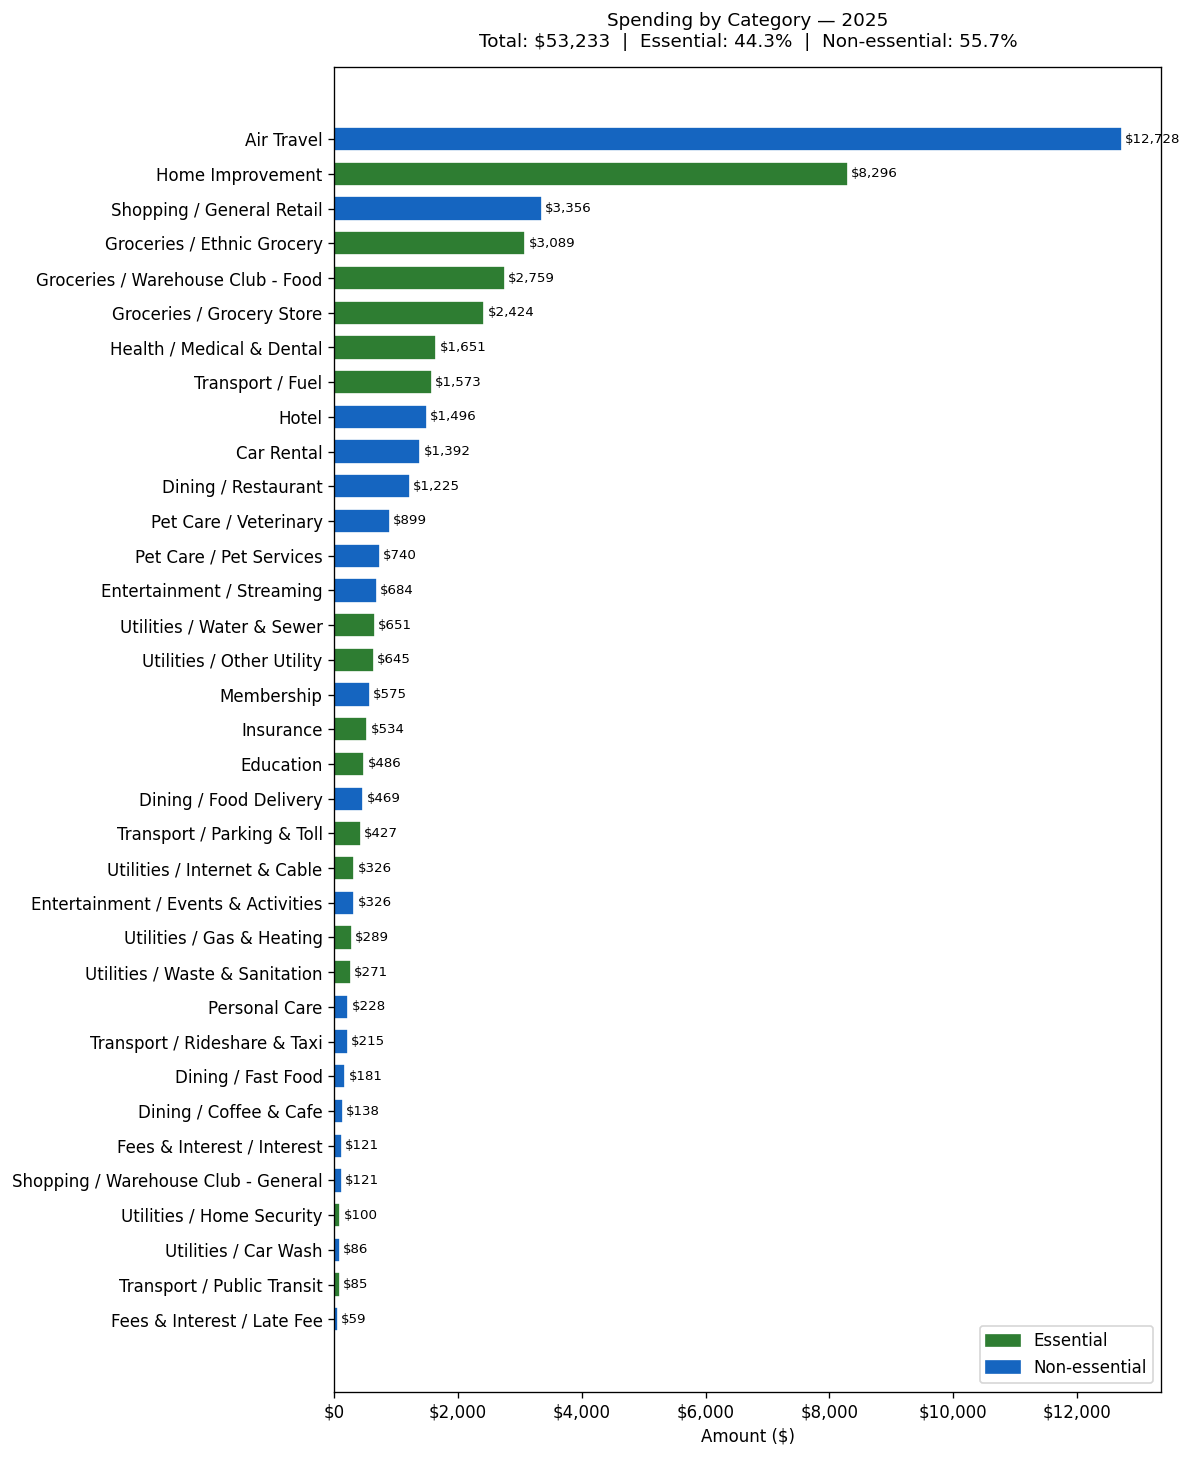

Saved: chart1_categories.png


In [2]:
df_cat = pd.DataFrame(cat_data['categories'])
df_cat = df_cat[df_cat['category'] != 'Other'].copy()
df_cat['label'] = df_cat.apply(
    lambda r: r['category'] if r['category'] == r['subcategory']
              else f"{r['category']} / {r['subcategory']}", axis=1)
df_cat = df_cat.sort_values('total')

colors = ['#2E7D32' if e else '#1565C0' for e in df_cat['is_essential']]

fig, ax = plt.subplots(figsize=(10, max(6, len(df_cat) * 0.35)))
bars = ax.barh(df_cat['label'], df_cat['total'], color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, df_cat['total']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=8)

ax.set_xlabel('Amount ($)')
ax.set_title(f'Spending by Category — {YEAR}\n'
             f'Total: ${cat_data["grand_total"]:,.0f}  |  '
             f'Essential: {cat_data["essential_pct"]}%  |  '
             f'Non-essential: {cat_data["nonessential_pct"]}%',
             fontsize=11, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2E7D32', label='Essential'),
                   Patch(color='#1565C0', label='Non-essential')],
          loc='lower right')

plt.tight_layout()
plt.savefig('/home/fintrack/notebooks/chart1_categories.png', bbox_inches='tight')
plt.show()
print('Saved: chart1_categories.png')

## Chart 2 — Monthly Trend

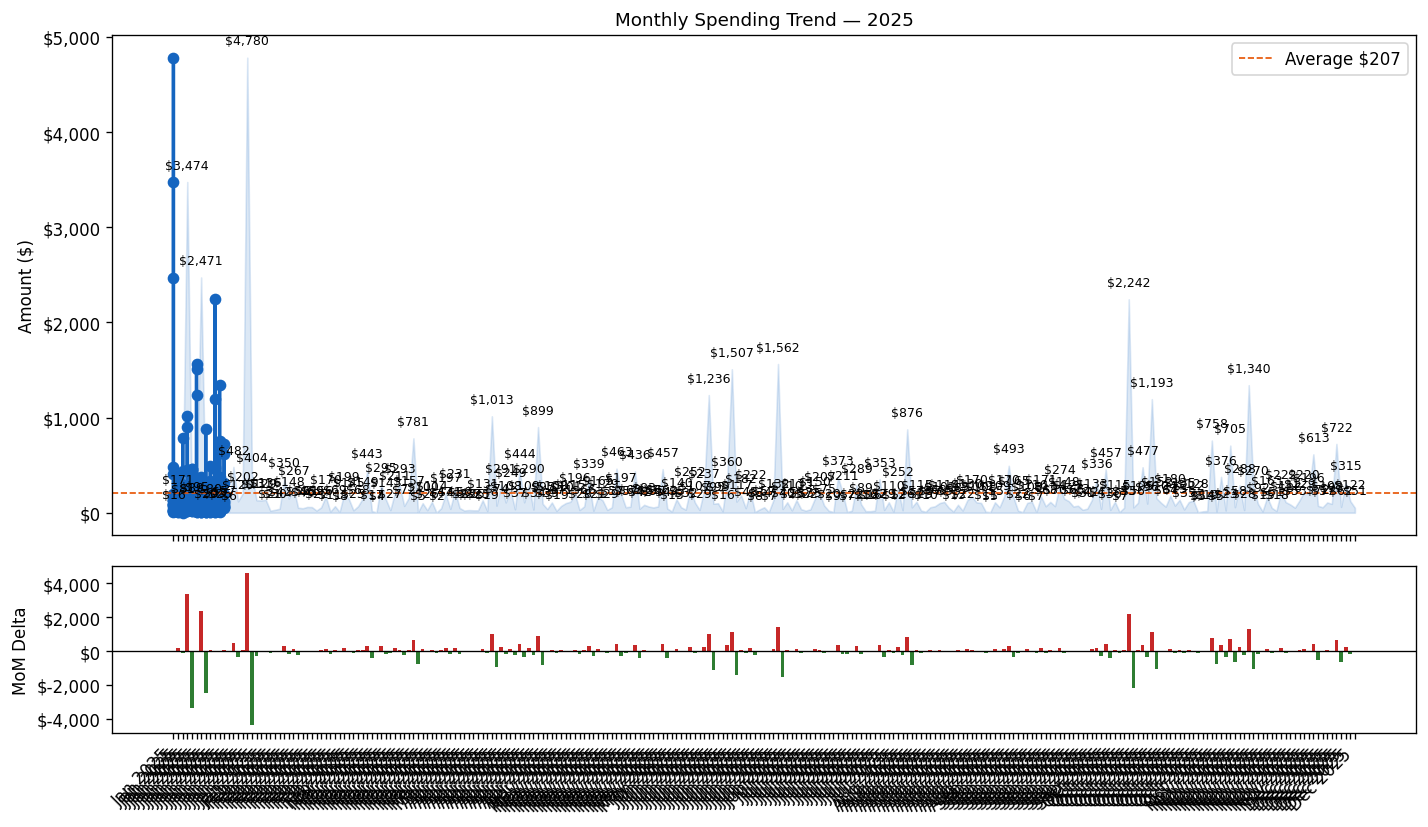

Saved: chart2_trend.png


In [3]:
df_trend = pd.DataFrame(trend_data['months'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# Monthly spend line
ax1.plot(df_trend['month'], df_trend['total'], 'o-', color='#1565C0',
         linewidth=2, markersize=6)
ax1.fill_between(range(len(df_trend)), df_trend['total'],
                 alpha=0.15, color='#1565C0')
ax1.axhline(trend_data['average'], color='#E65100', linestyle='--',
            linewidth=1, label=f'Average ${trend_data["average"]:,.0f}')

for i, row in df_trend.iterrows():
    ax1.annotate(f'${row["total"]:,.0f}',
                 (i, row['total']), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=7.5)

ax1.set_ylabel('Amount ($)')
ax1.set_title(f'Monthly Spending Trend — {YEAR}', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend()
ax1.set_xticks(range(len(df_trend)))
ax1.set_xticklabels(df_trend['month'], rotation=45, ha='right')

# MoM delta bar
delta_colors = ['#2E7D32' if d <= 0 else '#C62828' for d in df_trend['mom_delta']]
ax2.bar(range(len(df_trend)), df_trend['mom_delta'], color=delta_colors)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('MoM Delta')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_xticks(range(len(df_trend)))
ax2.set_xticklabels(df_trend['month'], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('/home/fintrack/notebooks/chart2_trend.png', bbox_inches='tight')
plt.show()
print('Saved: chart2_trend.png')

## Chart 3 — Essential vs Non-Essential (stacked bar)

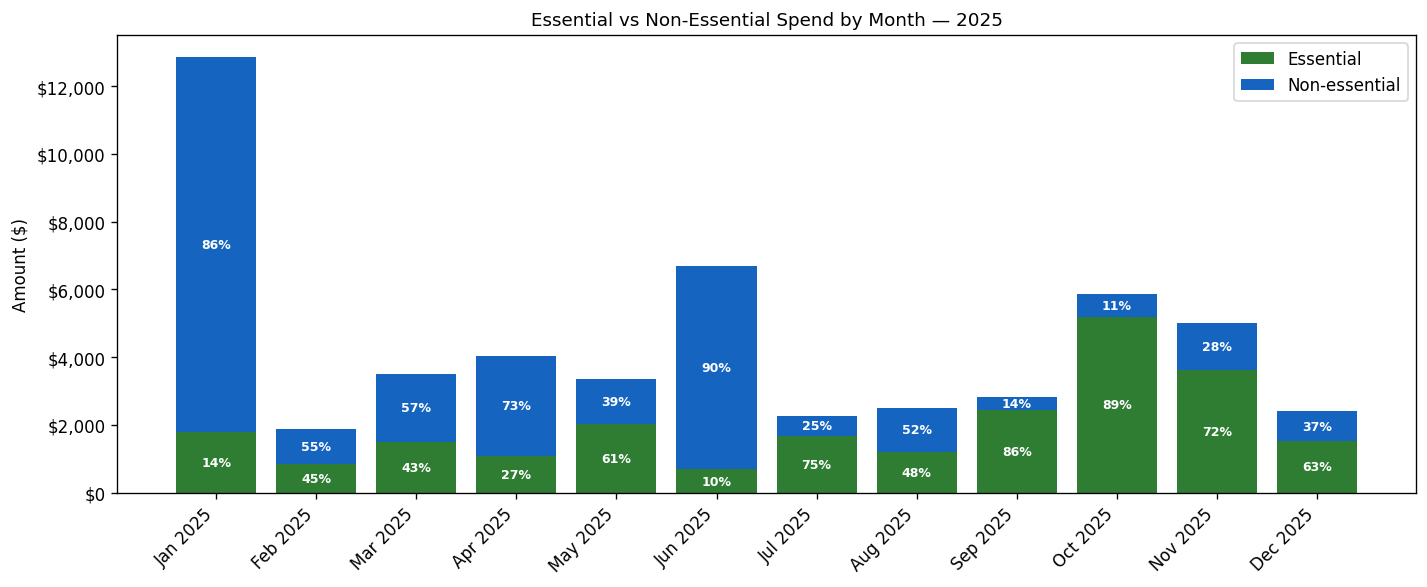

Saved: chart3_essential_split.png


In [4]:
df_split = pd.DataFrame(split_data['months'])

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(df_split))

b1 = ax.bar(x, df_split['essential'],    label='Essential',    color='#2E7D32')
b2 = ax.bar(x, df_split['nonessential'], bottom=df_split['essential'],
            label='Non-essential', color='#1565C0')

# % labels
for i, row in df_split.iterrows():
    if row['total'] > 0:
        ax.text(i, row['essential'] / 2,
                f"{row['essential_pct']:.0f}%",
                ha='center', va='center', color='white', fontsize=7.5, fontweight='bold')
        ax.text(i, row['essential'] + row['nonessential'] / 2,
                f"{row['nonessential_pct']:.0f}%",
                ha='center', va='center', color='white', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df_split['month'], rotation=45, ha='right')
ax.set_ylabel('Amount ($)')
ax.set_title(f'Essential vs Non-Essential Spend by Month — {YEAR}', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig('/home/fintrack/notebooks/chart3_essential_split.png', bbox_inches='tight')
plt.show()
print('Saved: chart3_essential_split.png')

## Chart 4 — Monthly Pivot Heatmap

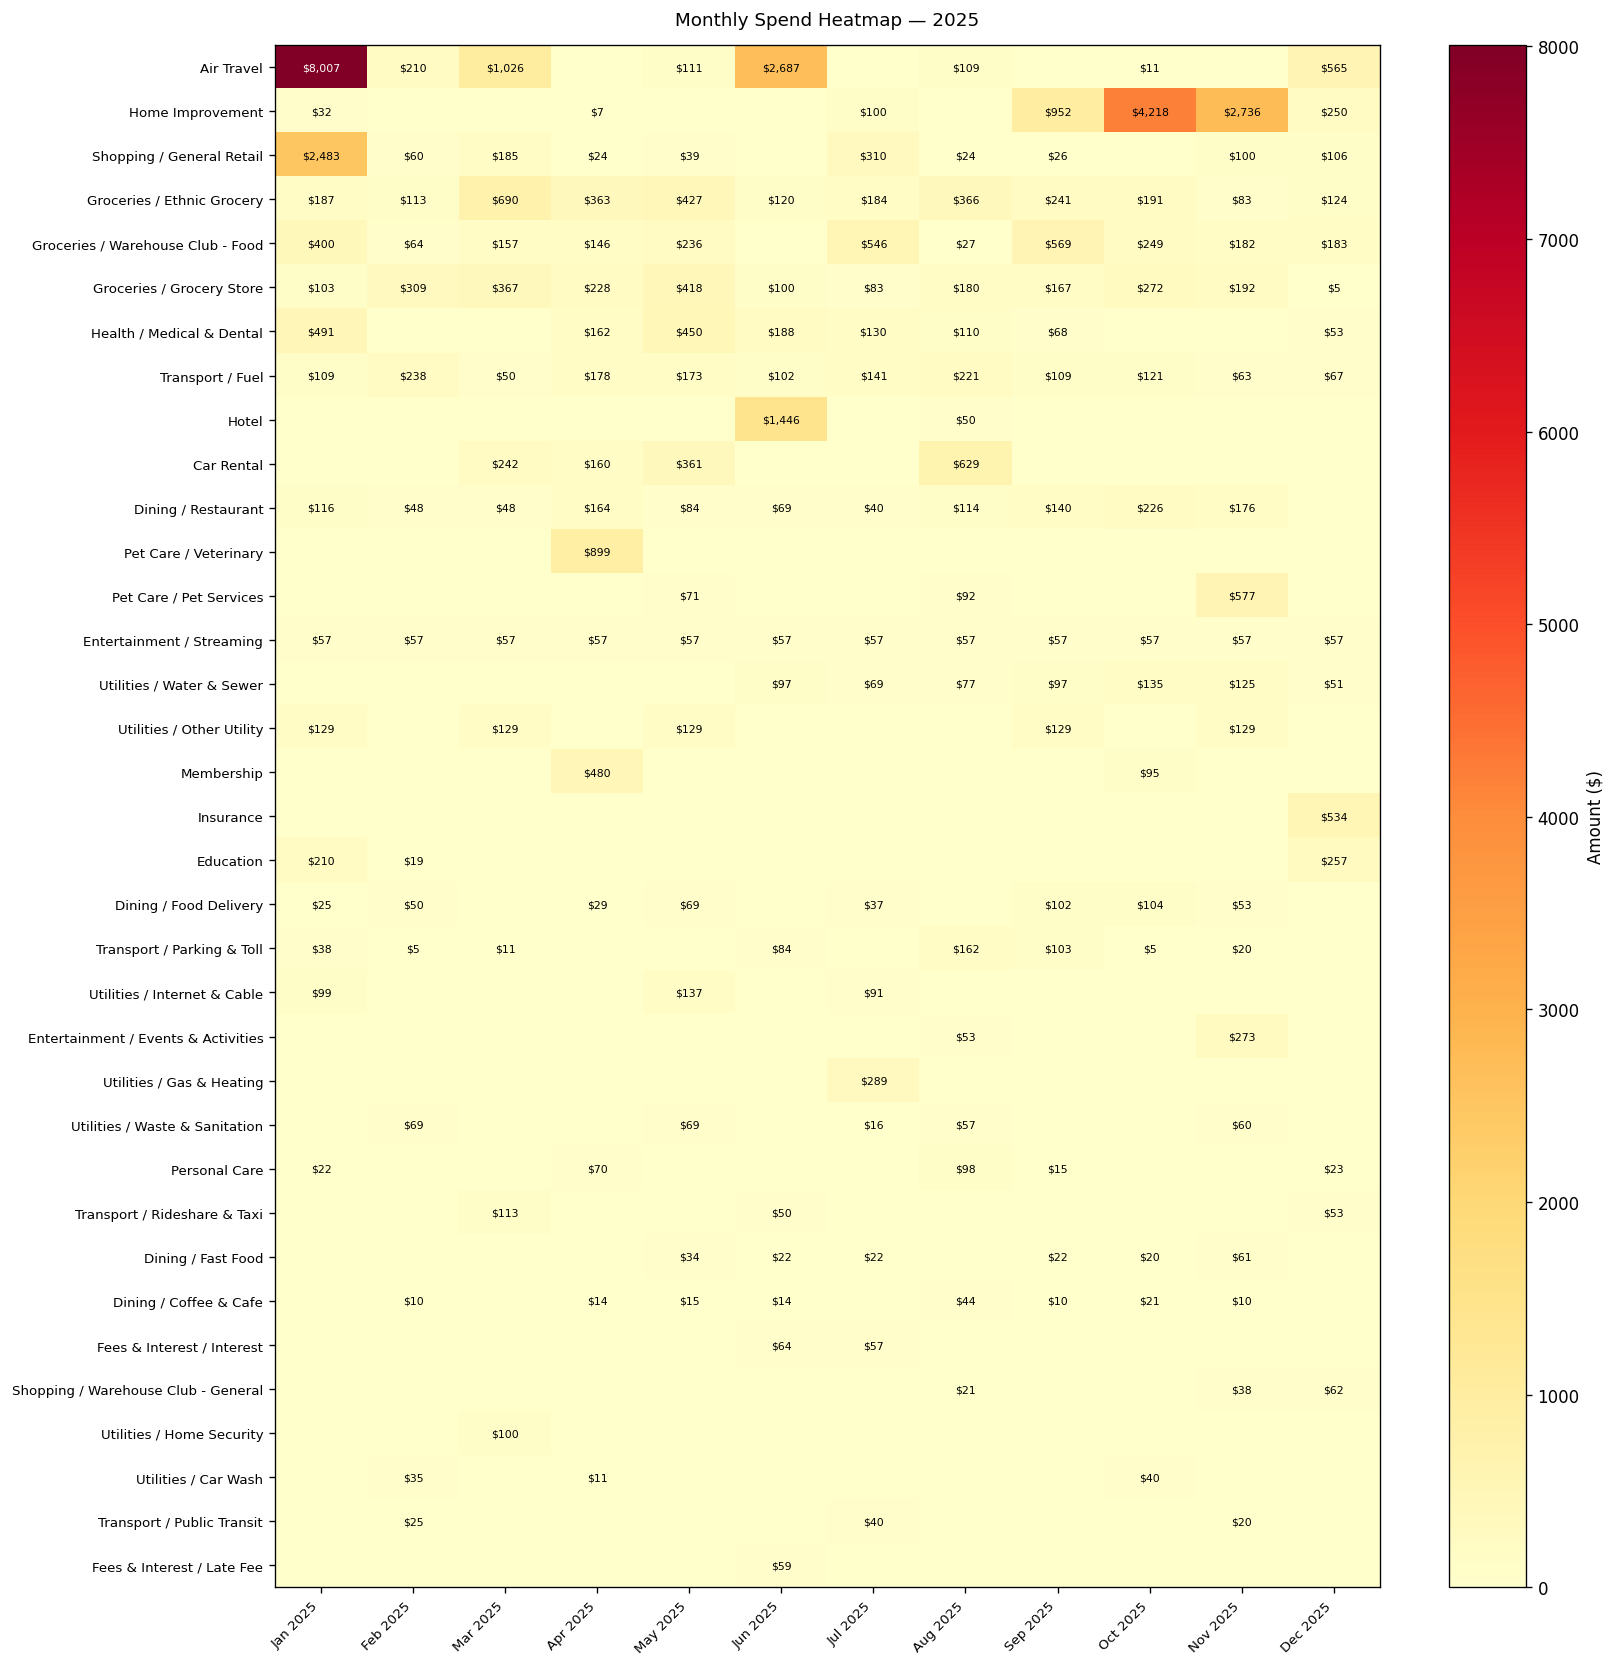

Saved: chart4_heatmap.png


In [5]:
months = pivot_data['months']
rows   = pivot_data['rows']

# Build matrix — exclude Other for cleaner view
labels = [f"{r['category']} / {r['subcategory']}" if r['category'] != r['subcategory']
          else r['category']
          for r in rows if r['category'] != 'Other']
matrix = np.array([[r['months'].get(m, 0) for m in months]
                   for r in rows if r['category'] != 'Other'])

fig, ax = plt.subplots(figsize=(14, max(6, len(labels) * 0.4)))
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)

# Annotate cells with values
for i in range(len(labels)):
    for j in range(len(months)):
        val = matrix[i, j]
        if val > 0:
            ax.text(j, i, f'${val:,.0f}', ha='center', va='center',
                    fontsize=6.5,
                    color='white' if val > matrix.max() * 0.6 else 'black')

plt.colorbar(im, ax=ax, label='Amount ($)')
ax.set_title(f'Monthly Spend Heatmap — {YEAR}', fontsize=11, pad=12)
plt.tight_layout()
plt.savefig('/home/fintrack/notebooks/chart4_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: chart4_heatmap.png')

## Chart 5 — Utility Seasonal Breakdown

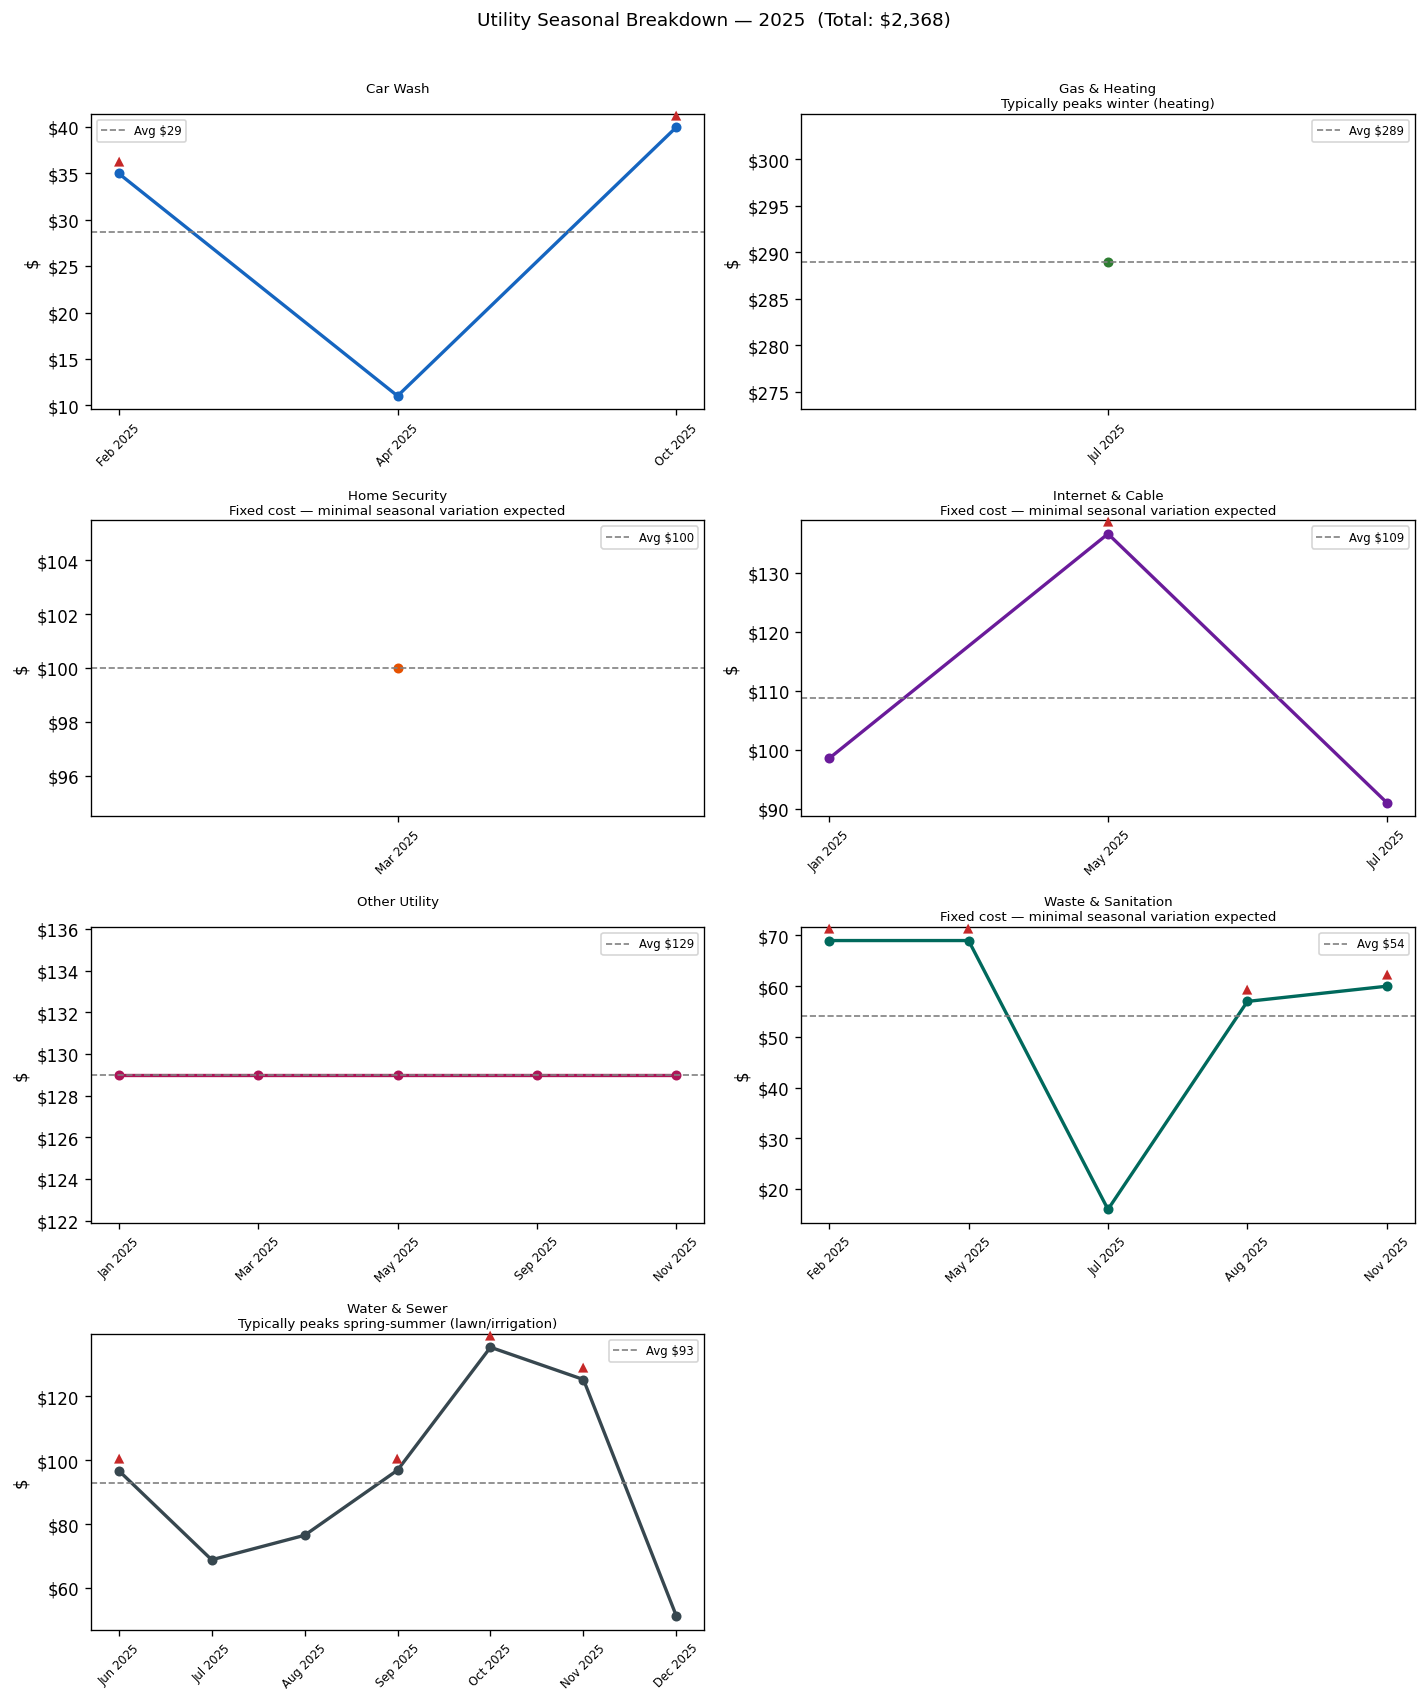

Saved: chart5_utilities.png


In [6]:
util_types = util_data['utility_types']
n_types    = len(util_types)

if n_types == 0:
    print('No utility data for this year')
else:
    cols = min(2, n_types)
    rows_n = (n_types + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(12, rows_n * 3.5))
    axes = np.array(axes).flatten() if n_types > 1 else [axes]

    colors_line = ['#1565C0','#2E7D32','#E65100','#6A1B9A','#AD1457','#00695C','#37474F']

    for idx, ut in enumerate(util_types):
        ax  = axes[idx]
        mdf = pd.DataFrame(ut['months'])
        if mdf.empty:
            continue

        color = colors_line[idx % len(colors_line)]
        ax.plot(mdf['month'], mdf['amount'], 'o-', color=color,
                linewidth=2, markersize=5)
        ax.axhline(ut['yearly_avg'], color='grey', linestyle='--',
                   linewidth=1, label=f'Avg ${ut["yearly_avg"]:,.0f}')

        # Highlight above-average months
        for _, row in mdf[mdf['above_average']].iterrows():
            ax.annotate('▲', (row['month'], row['amount']),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', color='#C62828', fontsize=8)

        ax.set_title(f"{ut['utility_type']}\n{ut['seasonal_note']}",
                     fontsize=8, pad=4)
        ax.set_ylabel('$')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        ax.legend(fontsize=7)

    # Hide unused subplots
    for idx in range(n_types, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(f'Utility Seasonal Breakdown — {YEAR}  '
                 f'(Total: ${util_data["total_utility_spend"]:,.0f})',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig('/home/fintrack/notebooks/chart5_utilities.png', bbox_inches='tight')
    plt.show()
    print('Saved: chart5_utilities.png')